In [1]:
import pandas as pd
import numpy as np


In [2]:
feature_df = pd.read_csv("../data/processed/driver_race_features.csv")
print(feature_df.shape)
feature_df.head()


(25121, 17)


,season,round,raceId,race_date,driverId,driver_name,constructorId,constructor_name,circuitId,circuit_name,grid,driver_experience,driver_recent_form,constructor_strength,era,grid_bucket,target_top10
0,1950,1,833,1950-05-13,579,Juan Fangio,51,Alfa Romeo,9,Silverstone Circuit,3,0,11.754182,11.823009,1950-1969,front_row_1_3,0
1,1950,1,833,1950-05-13,589,Louis Chiron,105,Maserati,9,Silverstone Circuit,11,0,11.754182,11.823009,1950-1969,mid_11_20,0
2,1950,1,833,1950-05-13,619,Bob Gerard,151,ERA,9,Silverstone Circuit,13,0,11.754182,11.823009,1950-1969,mid_11_20,1
3,1950,1,833,1950-05-13,627,Louis Rosier,154,Talbot-Lago,9,Silverstone Circuit,9,0,11.754182,11.823009,1950-1969,top10_4_10,1
4,1950,1,833,1950-05-13,640,Toulo de Graffenried,105,Maserati,9,Silverstone Circuit,8,0,11.754182,18.000000,1950-1969,top10_4_10,0


In [3]:
y = feature_df["target_top10"]

X = feature_df.drop(columns=[
    "target_top10",
    "race_date",       
    "driver_name",
    "constructor_name",
    "circuit_name"
])

X = X.drop(columns=["raceId"], errors="ignore")

print(X.shape, y.shape)


(25121, 11) (25121,)


In [4]:
cat_cols = ["circuitId", "era", "grid_bucket"]

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Encoded:", X_encoded.shape)


Encoded: (25121, 91)


In [9]:
print(y.value_counts())
print(y.value_counts(normalize=True))


target_top10
0    13814
1    11307
Name: count, dtype: int64
target_top10
0    0.549898
1    0.450102
Name: proportion, dtype: float64


In [12]:
X_encoded.dtypes.value_counts()


bool       83
int64       6
float64     2
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

num_cols = ["grid", "driver_experience", "driver_recent_form", "constructor_strength", "round", "season"]
num_cols = [c for c in num_cols if c in X_encoded.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)

logreg = LogisticRegression(max_iter=5000, solver="lbfgs")

pipeline_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", logreg)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1"]

scores_lr = cross_validate(
    pipeline_lr,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise"
)

for m in scoring:
    vals = scores_lr[f"test_{m}"]
    print(f"LogReg {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction

LogReg accuracy: mean=0.677, std=0.008
LogReg precision: mean=0.649, std=0.009
LogReg recall: mean=0.617, std=0.012
LogReg f1: mean=0.632, std=0.010


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

scores_rf = cross_validate(
    rf,
    X_encoded,
    y,
    cv=cv,  # same StratifiedKFold as before
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

for m in ["accuracy", "precision", "recall", "f1"]:
    vals = scores_rf[f"test_{m}"]
    print(f"RF {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


RF accuracy: mean=0.677, std=0.008
RF precision: mean=0.656, std=0.009
RF recall: mean=0.594, std=0.010
RF f1: mean=0.623, std=0.009


In [16]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": scores_lr["test_accuracy"].mean(),
        "Precision_mean": scores_lr["test_precision"].mean(),
        "Recall_mean": scores_lr["test_recall"].mean(),
        "F1_mean": scores_lr["test_f1"].mean(),
        "Accuracy_std": scores_lr["test_accuracy"].std(),
        "Precision_std": scores_lr["test_precision"].std(),
        "Recall_std": scores_lr["test_recall"].std(),
        "F1_std": scores_lr["test_f1"].std(),
    },
    {
        "Model": "Random Forest",
        "Accuracy_mean": scores_rf["test_accuracy"].mean(),
        "Precision_mean": scores_rf["test_precision"].mean(),
        "Recall_mean": scores_rf["test_recall"].mean(),
        "F1_mean": scores_rf["test_f1"].mean(),
        "Accuracy_std": scores_rf["test_accuracy"].std(),
        "Precision_std": scores_rf["test_precision"].std(),
        "Recall_std": scores_rf["test_recall"].std(),
        "F1_std": scores_rf["test_f1"].std(),
    }
])

comparison


,Model,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,Accuracy_std,Precision_std,Recall_std,F1_std
0,Logistic Regression,0.677162,0.648760,0.616609,0.632241,0.007822,0.009365,0.011631,0.009546
1,Random Forest,0.677083,0.656123,0.593792,0.623382,0.007574,0.009362,0.010390,0.009292


Matplotlib is building the font cache; this may take a moment.


Text(0, 0.5, 'Score (mean over 5 folds)')

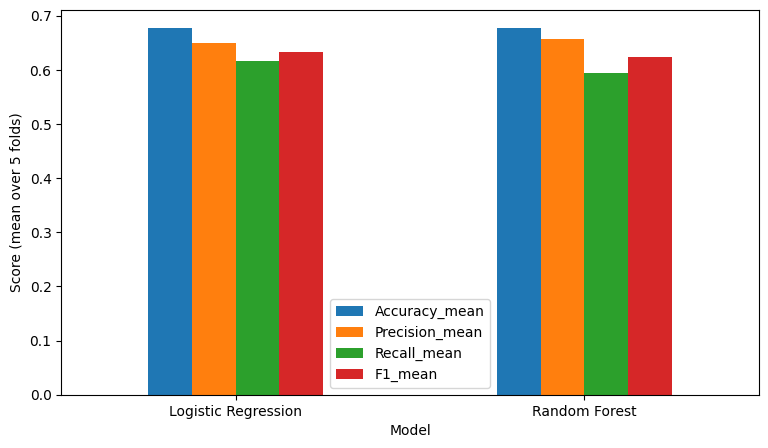

In [17]:
ax = comparison.set_index("Model")[["Accuracy_mean","Precision_mean","Recall_mean","F1_mean"]].plot.bar(rot=0, figsize=(9,5))
ax.set_ylabel("Score (mean over 5 folds)")


In [18]:
pipeline_lr.fit(X_encoded, y)

print("Final model (Logistic Regression) trained on full dataset.")

/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/clementine/Formula1/Formula1/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountere

Final model (Logistic Regression) trained on full dataset.


In [20]:
import joblib

joblib.dump(pipeline_lr, "../data/processed/final_model_logreg.joblib")

print("Final Logistic Regression model saved to data/processed/final_model_logreg.joblib")


Final Logistic Regression model saved to data/processed/final_model_logreg.joblib


In [21]:
model = pipeline_lr.named_steps["model"]

coef_series = (
    pd.Series(model.coef_[0], index=X_encoded.columns)
      .sort_values()
)

print("Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):")
print(coef_series.head(15))

print("\nStärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):")
print(coef_series.tail(15))

Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):
season                  -0.758167
era_1990-2009           -0.548392
era_1970-1989           -0.514166
era_2010-2021           -0.308007
circuitId_64            -0.223058
grid_bucket_mid_11_20   -0.199723
era_2022+               -0.175866
circuitId_58            -0.167902
circuitId_19            -0.152555
circuitId_35            -0.139802
circuitId_60            -0.121883
driverId                -0.109652
circuitId_67            -0.108148
circuitId_55            -0.107571
circuitId_68            -0.102930
dtype: float64

Stärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):
circuitId_48    0.073806
circuitId_76    0.080055
circuitId_6     0.084716
circuitId_53    0.092020
circuitId_45    0.110330
circuitId_75    0.121756
circuitId_52    0.127222
circuitId_61    0.134417
circuitId_65    0.144278
circuitId_54    0.169589
round           0.173678
circuitId_49    0.223249
circuitId_25    0.231648
circuitId_51